## Batch Parameters and Aggregation
This section lets you set parameters, call the R script for one or more CSVs, and aggregate results into a long-format summary where each row is a channel with `uL_mg_hr`, `temp_C`, and placeholder metadata.

In [1]:
# Batch-convert FireSting .txt files (Ostracods-*-Nov.txt) to standardized CSV
from pathlib import Path
import subprocess
import pandas as pd

DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
SCRIPT = Path('/Users/oakley/Documents/GitHub/signal_respirometry/scripts/convert_firesting_to_csv.py')

# Pattern: starts with 'Ostracods-' and ends with 'Nov.txt'
pattern = 'Ostracods-*Nov.txt'
overwrite = False  # set True to force regeneration

txt_files = sorted(DATA_DIR.glob(pattern))
results = []
for txt_path in txt_files:
    out_csv = DATA_DIR / f"{txt_path.stem}.csv"
    args = ['python3', str(SCRIPT), '--in', str(txt_path), '--out', str(out_csv)]
    if overwrite:
        args.append('--overwrite')
    try:
        subprocess.run(args, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        status = 'converted' if (overwrite or not out_csv.exists()) else 'exists'
        msg = ''
    except subprocess.CalledProcessError as e:
        # If output exists and overwrite=False, script raises FileExistsError; mark as skipped
        if out_csv.exists() and not overwrite:
            status = 'skipped'
            msg = 'exists (use overwrite to regenerate)'
        else:
            status = 'failed'
            msg = e.stderr.decode('utf-8', errors='ignore') if e.stderr else str(e)
    results.append({'txt': str(txt_path), 'csv': str(out_csv), 'status': status, 'message': msg})

if results:
    df = pd.DataFrame(results)
    display(df)
else:
    print('No matching .txt files found for pattern:', pattern)

,txt,csv,status,message
0,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
1,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
2,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
3,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
4,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
5,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
6,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
7,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
8,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)
9,/Users/oakley/Documents/GitHub/signal_respirom...,/Users/oakley/Documents/GitHub/signal_respirom...,skipped,exists (use overwrite to regenerate)


In [18]:
# Convert trial newbox directories to legacy-format CSVs for R (seconds,hours,clock,Ch1..Ch4,Temp)
from pathlib import Path
import pandas as pd, re
BASE = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
trial_dirs = sorted(BASE.glob('Ostracods-trial*newbox-*Nov'))

rows_summary = []

oxygen_file_pattern = re.compile(r'.*\(A Ch\.(\d)\)_Oxygen.txt$')

for tdir in trial_dirs:
    # Find timestamp subdirectory (one level down) containing MeasurementData
    timestamp_subdirs = [p for p in tdir.iterdir() if p.is_dir() and any(child.name=='MeasurementData' for child in p.iterdir())]
    if not timestamp_subdirs:
        rows_summary.append({'trial_dir': tdir.name, 'status': 'no-timestamp-subdir', 'csv': None, 'channels': None})
        continue
    ts = timestamp_subdirs[0]
    mdata = ts / 'MeasurementData'
    if not mdata.exists():
        rows_summary.append({'trial_dir': tdir.name, 'status': 'no-MeasurementData', 'csv': None, 'channels': None})
        continue
    oxygen_files = [p for p in mdata.iterdir() if p.is_file() and oxygen_file_pattern.match(str(p))]
    if not oxygen_files:
        rows_summary.append({'trial_dir': tdir.name, 'status': 'no-oxygen-files', 'csv': None, 'channels': None})
        continue

    # Parse per-channel into a unified time index `seconds` and channel columns Ch1..Ch4
    channel_frames = {}
    for ofile in oxygen_files:
        ch_match = oxygen_file_pattern.match(str(ofile))
        ch_id = ch_match.group(1) if ch_match else None
        if ch_id is None:
            continue
        with ofile.open('r', errors='ignore') as f:
            lines = f.readlines()
        # Find marker and header
        try:
            start_idx = next(i for i,l in enumerate(lines) if l.startswith('#--- Measurement Data'))
        except StopIteration:
            rows_summary.append({'trial_dir': tdir.name, 'status': f'no-data-marker-{ofile.name}', 'csv': None, 'channels': None})
            continue
        data_lines = lines[start_idx+1:]
        if not data_lines:
            rows_summary.append({'trial_dir': tdir.name, 'status': f'empty-data-{ofile.name}', 'csv': None, 'channels': None})
            continue
        header_line = data_lines[0].rstrip('\n')
        header_clean = re.sub(r'\s+', '\t', header_line).strip()
        header_cols = [h for h in header_clean.split('\t') if h]
        # Collect rows
        rows = []
        for dl in data_lines[1:]:
            dl = dl.strip('\n')
            if not dl or dl.startswith('#'):
                continue
            dl_clean = re.sub(r'\s+', '\t', dl).strip()
            parts = [p for p in dl_clean.split('\t') if p]
            if len(parts) < 2:
                continue
            parts = parts[:len(header_cols)]
            rows.append(parts)
        if not rows:
            continue
        df_ch = pd.DataFrame(rows, columns=header_cols[:len(rows[0])])
        # Find seconds and oxygen columns
        def find_col(df, includes):
            for c in df.columns:
                if all(s.lower() in c.lower() for s in includes):
                    return c
            return None
        sec_col = find_col(df_ch, ['dt', '(s)']) or find_col(df_ch, ['Time', '(s)'])
        oxy_col = find_col(df_ch, ['Oxygen', 'Main']) or find_col(df_ch, ['Oxygen'])
        temp_col = find_col(df_ch, ['Sample', 'Temp']) or find_col(df_ch, ['Temp'])
        if sec_col is None or oxy_col is None:
            rows_summary.append({'trial_dir': tdir.name, 'status': f'missing-sec-or-oxy-{ofile.name}', 'csv': None, 'channels': None})
            continue
        df_sel = pd.DataFrame({
            'seconds': pd.to_numeric(df_ch[sec_col], errors='coerce'),
            f'Ch{ch_id}': pd.to_numeric(df_ch[oxy_col], errors='coerce'),
        })
        if temp_col and temp_col in df_ch.columns:
            df_sel[f'temp_C_Ch{ch_id}'] = pd.to_numeric(df_ch[temp_col], errors='coerce')
        df_sel = df_sel.dropna(subset=['seconds'])
        channel_frames[ch_id] = df_sel

    if not channel_frames:
        rows_summary.append({'trial_dir': tdir.name, 'status': 'parsed-none', 'csv': None, 'channels': None})
        continue

    # Merge channels on seconds
    from functools import reduce
    merged = None
    for ch_id, df_sel in sorted(channel_frames.items()):
        if merged is None:
            merged = df_sel.copy()
        else:
            merged = pd.merge(merged, df_sel, on='seconds', how='outer')
    merged.sort_values('seconds', inplace=True)
    merged['hours'] = merged['seconds'] / 3600.0
    # clock column not available from per-channel Oxygen files; include empty strings
    merged['clock'] = ''
    # Compose Temp from available temp_C_Ch* (row-wise mean)
    temp_cols = [c for c in merged.columns if c.startswith('temp_C_Ch')]
    if temp_cols:
        merged['Temp'] = merged[temp_cols].mean(axis=1)
    else:
        merged['Temp'] = pd.NA

    # Ensure channels Ch1..Ch4 exist
    for ch in ['Ch1','Ch2','Ch3','Ch4']:
        if ch not in merged.columns:
            merged[ch] = pd.NA

    out = merged[['seconds','hours','clock','Ch1','Ch2','Ch3','Ch4','Temp']].copy()
    out_csv = BASE / f'{tdir.name}.csv'
    out.to_csv(out_csv, index=False)
    rows_summary.append({'trial_dir': tdir.name, 'status': 'converted', 'csv': str(out_csv), 'channels': len(channel_frames)})

summary_df = pd.DataFrame(rows_summary)
print('Conversion summary (legacy format):')
print(summary_df)


Conversion summary (legacy format):
                              trial_dir  \
0         Ostracods-trial1-newbox-10Nov   
1         Ostracods-trial1-newbox-10Nov   
2         Ostracods-trial1-newbox-10Nov   
3         Ostracods-trial1-newbox-10Nov   
4         Ostracods-trial1-newbox-10Nov   
5         Ostracods-trial2-newbox-11Nov   
6         Ostracods-trial2-newbox-11Nov   
7         Ostracods-trial2-newbox-11Nov   
8         Ostracods-trial2-newbox-11Nov   
9         Ostracods-trial2-newbox-11Nov   
10        Ostracods-trial3-newbox-12Nov   
11        Ostracods-trial3-newbox-12Nov   
12        Ostracods-trial3-newbox-12Nov   
13        Ostracods-trial3-newbox-12Nov   
14        Ostracods-trial3-newbox-12Nov   
15        Ostracods-trial4-newbox-13Nov   
16        Ostracods-trial4-newbox-13Nov   
17        Ostracods-trial4-newbox-13Nov   
18        Ostracods-trial4-newbox-13Nov   
19        Ostracods-trial4-newbox-13Nov   
20  Ostracods-trial5-light-newbox-15Nov   
21  Ostracods-tria

In [ ]:
# Configure batch inputs and aggregate per-channel (multi-run, generalized R script)
import pandas as pd
from pathlib import Path
import subprocess, shlex

DATA_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
OUT_DIR = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed')
R_SCRIPT = Path('/Users/oakley/Documents/GitHub/signal_respirometry/scripts/consumption_rate.R')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Restore full list of runs (newbox trials 1–7; dark/light where available)
# Note: filenames must exist in DATA_DIR; this will skip missing CSVs.
# Parameters follow prior convention (small vessels, control Ch1, channels Ch2–Ch4).
common = {
    'brick': 'newpyro',
    'sal': 33,
    'control': 'Ch1',
    'channels': ['Ch2', 'Ch3', 'Ch4'],
    'masses': [0.00024, 0.00024, 0.00024],
    'vol_control': 0.002,
    'volumes': [0.002, 0.002, 0.002],
    # Use broad windows so R has enough rows; adjust later per trial if needed
    'start_hour': 0,
    'end_hour': 24,
    'microbial_cutoff_hour': 0,
}

runs = [
    {**common, 'trial': 'trial1', 'csv': DATA_DIR / 'Ostracods-trial1-newbox-10Nov.csv', 'metadata': {'vessel': 'small', 'date': '10Nov2025', 'environment': 'dark'}},
    {**common, 'trial': 'trial2', 'csv': DATA_DIR / 'Ostracods-trial2-newbox-11Nov.csv', 'metadata': {'vessel': 'small', 'date': '11Nov2025', 'environment': 'dark'}},
    {**common, 'trial': 'trial3', 'csv': DATA_DIR / 'Ostracods-trial3-newbox-12Nov.csv', 'metadata': {'vessel': 'small', 'date': '12Nov2025', 'environment': 'dark'}},
    {**common, 'trial': 'trial4', 'csv': DATA_DIR / 'Ostracods-trial4-newbox-13Nov.csv', 'metadata': {'vessel': 'small', 'date': '13Nov2025', 'environment': 'dark'}},
    # Trial 5: dark on 14 Nov, light on 15 Nov
    {**common, 'trial': 'trial5-dark', 'csv': DATA_DIR / 'Ostracods-trial5-newbox-14Nov.csv', 'metadata': {'vessel': 'small', 'date': '14Nov2025', 'environment': 'dark'}},
    {**common, 'trial': 'trial5-light', 'csv': DATA_DIR / 'Ostracods-trial5-light-newbox-15Nov.csv', 'metadata': {'vessel': 'small', 'date': '15Nov2025', 'environment': 'light'}},
    # Trial 6: light and dark on 16 Nov
    {**common, 'trial': 'trial6-light', 'csv': DATA_DIR / 'Ostracods-trial6-light-newbox-16Nov.csv', 'metadata': {'vessel': 'small', 'date': '16Nov2025', 'environment': 'light'}},
    {**common, 'trial': 'trial6-dark', 'csv': DATA_DIR / 'Ostracods-trial6-dark-newbox-16Nov.csv', 'metadata': {'vessel': 'small', 'date': '16Nov2025', 'environment': 'dark'}},
    # Trial 7: light and dark on 17 Nov
    {**common, 'trial': 'trial7-light', 'csv': DATA_DIR / 'Ostracods-trial7-light-newbox-17Nov.csv', 'metadata': {'vessel': 'small', 'date': '17Nov2025', 'environment': 'light'}},
    {**common, 'trial': 'trial7-dark', 'csv': DATA_DIR / 'Ostracods-trial7-dark-newbox-17Nov.csv', 'metadata': {'vessel': 'small', 'date': '17Nov2025', 'environment': 'dark'}},
]

master_summary = OUT_DIR / 'batch_r_summary_channels.csv'
rows = []

required_keys = ['csv','sal','control','channels','masses','vol_control','volumes','start_hour','end_hour','microbial_cutoff_hour']

for run in runs:
    if any(k not in run for k in required_keys):
        print('Skipping incomplete run:', {k: run.get(k) for k in ['brick','trial','csv']})
        continue

    csv_path = run['csv']
    if not csv_path.exists():
        print(f'CSV not found on disk: {csv_path}')
        continue

    args = [
        'Rscript', '--vanilla', str(R_SCRIPT),
        '--csv', str(csv_path),
        '--sal', str(run['sal']),
        '--control', run['control'],
        '--channels', ','.join(run['channels']),
        '--masses', ','.join(str(m) for m in run['masses']),
        '--vol_control', str(run['vol_control']),
        '--volumes', ','.join(str(v) for v in run['volumes']),
        '--start_hour', str(run['start_hour']),
        '--end_hour', str(run['end_hour']),
        '--microbial_cutoff_hour', str(run['microbial_cutoff_hour']),
        '--out', str(OUT_DIR),
    ]
    if 'mask_channels' in run:
        args += ['--mask_channels', str(bool(run['mask_channels'])).lower()]
    if 'cutoff_inclusive' in run:
        args += ['--cutoff_inclusive', str(bool(run['cutoff_inclusive'])).lower()]
    if 'debug' in run:
        args += ['--debug', str(bool(run['debug'])).lower()]

    try:
        completed = subprocess.run(args, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    except subprocess.CalledProcessError as e:
        print('Rscript failed with non-zero exit code.')
        print('Command:', ' '.join(shlex.quote(a) for a in args))
        if e.stdout:
            print('--- R stdout ---')
            try:
                print(e.stdout.decode('utf-8', errors='ignore'))
            except Exception:
                print(str(e.stdout))
        if e.stderr:
            print('--- R stderr ---')
            try:
                print(e.stderr.decode('utf-8', errors='ignore'))
            except Exception:
                print(str(e.stderr))
        continue

    r_summary_path = OUT_DIR / f"{Path(csv_path).name}_R_summary.csv"
    if not r_summary_path.exists():
        print(f"R summary not found: {r_summary_path}")
        continue

    df = pd.read_csv(r_summary_path)

    temp_C = float(df.loc[0, 'temp_C']) if 'temp_C' in df.columns else None
    metadata = run['metadata']

    stem_parts = Path(csv_path).stem.split('-')
    brick = run.get('brick') or (stem_parts[0] if stem_parts else None)
    trial = run.get('trial') or ('-'.join(stem_parts[1:]) if len(stem_parts) > 1 else None)

    for ch in run['channels']:
        col = f'{ch}_uL_mg_hr'
        if col not in df.columns:
            print(f"Missing expected column {col} in {r_summary_path}; available: {list(df.columns)}")
            continue
        rows.append({
            'file': str(csv_path),
            'brick': brick,
            'trial': trial,
            'channel': ch,
            'uL_mg_hr': float(df.loc[0, col]),
            'temp_C': temp_C,
            **metadata,
        })

if rows:
    agg_df = pd.DataFrame(rows)
    agg_df.to_csv(master_summary, index=False)
    display(agg_df)
else:
    print('No rows aggregated.')

Rscript failed with non-zero exit code.
Command: Rscript --vanilla /Users/oakley/Documents/GitHub/signal_respirometry/scripts/consumption_rate.R --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025/Ostracods-trial4-newbox-13Nov.csv --sal 33 --control Ch1 --channels Ch2,Ch3,Ch4 --masses 0.00024,0.00024,0.00024 --vol_control 0.002 --volumes 0.002,0.002,0.002 --start_hour 0 --end_hour 9 --microbial_cutoff_hour 4 --out /Users/oakley/Documents/GitHub/signal_respirometry/data/processed
--- R stderr ---
Error: Trimmed data has fewer than 5 rows; adjust hour window
Execution halted

No rows aggregated.


/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_33342/1145177654.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=order, showfliers=False, patch_artist=True)


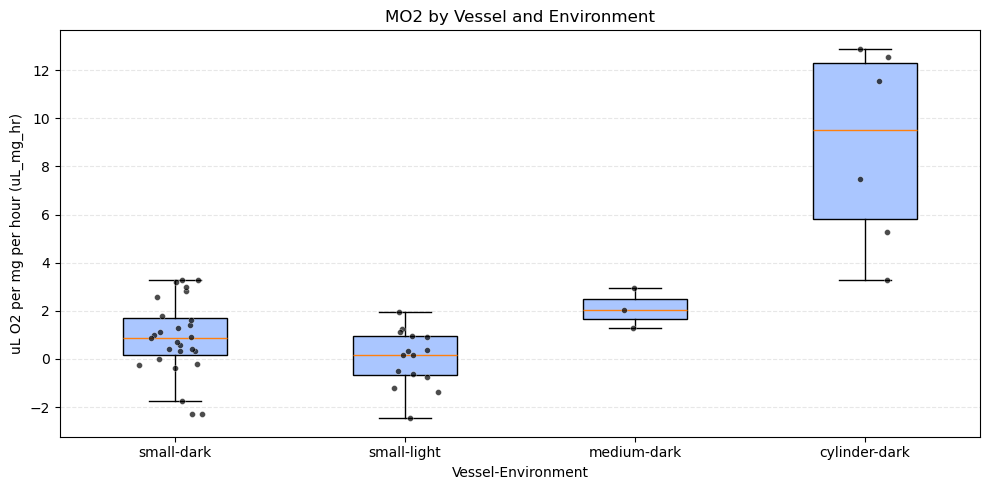

In [5]:
# Box+points plot of MO2 by vessel+environment (separate columns)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Get the aggregated data frame
try:
    df = agg_df.copy()
except NameError:
    try:
        df = pd.read_csv(master_summary)
    except Exception:
        fallback = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_r_summary_channels.csv')
        if not fallback.exists():
            raise FileNotFoundError('No agg_df in memory and fallback CSV not found at: ' + str(fallback))
        df = pd.read_csv(fallback)

# Basic validation
required_cols = {'vessel', 'environment', 'uL_mg_hr'}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f'Missing columns for plot: {missing}. Available: {list(df.columns)}')

# Prepare combined x category: '<vessel>-<environment>'
plot_df = df.dropna(subset=['uL_mg_hr', 'vessel']).copy()
plot_df['environment'] = plot_df['environment'].fillna('dark')
plot_df['vessel_env'] = plot_df['vessel'].astype(str) + '-' + plot_df['environment'].astype(str)

# Desired order: small-dark, small-light, medium-dark, cylinder-dark (skip light for medium/cylinder)
present = set(plot_df['vessel_env'].unique())
preferred_order = ['small-dark', 'small-light', 'medium-dark', 'cylinder-dark']
order = [x for x in preferred_order if x in present] + [x for x in sorted(present) if x not in preferred_order]

# Try seaborn; fall back to matplotlib
use_seaborn = False
try:
    import seaborn as sns
    use_seaborn = True
except Exception:
    use_seaborn = False

plt.figure(figsize=(10, 5))
if use_seaborn:
    sns.boxplot(data=plot_df, x='vessel_env', y='uL_mg_hr', order=order, showfliers=False, color='#aac6ff')
    sns.stripplot(
        data=plot_df,
        x='vessel_env', y='uL_mg_hr', order=order,
        jitter=0.2, dodge=False,
        marker='o', color='black', edgecolor='white', linewidth=0.3,
        alpha=0.6, zorder=3
    )
else:
    grouped = {k: plot_df.loc[plot_df['vessel_env'] == k, 'uL_mg_hr'].values for k in order}
    data = [grouped[k] for k in order]
    bp = plt.boxplot(data, labels=order, showfliers=False, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#aac6ff')
        patch.set_alpha(1.0)
    for i, k in enumerate(order, start=1):
        y = grouped[k]
        if len(y) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.06, size=len(y))
        plt.scatter(x, y, s=18, alpha=0.7, color='black', marker='o', edgecolors='white', linewidths=0.3, zorder=3)

plt.xlabel('Vessel-Environment')
plt.ylabel('uL O2 per mg per hour (uL_mg_hr)')
plt.title('MO2 by Vessel and Environment')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Statistical comparison: small-light vs small-dark MO2
import pandas as pd, numpy as np
from pathlib import Path
master_summary_path = master_summary if 'master_summary' in globals() else Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_r_summary_channels.csv')
try:
    df_stats = agg_df.copy()
except NameError:
    if not master_summary_path.exists():
        raise FileNotFoundError(f'Aggregated summary not found at {master_summary_path}. Run aggregation cell first.')
    df_stats = pd.read_csv(master_summary_path)
subset = df_stats[(df_stats['vessel']=='small') & (df_stats['environment'].isin(['dark','light']))].copy()
if subset.empty:
    raise ValueError('No small vessel data for dark/light comparison.')
groups = {env: subset.loc[subset['environment']==env,'uL_mg_hr'].dropna().values for env in ['dark','light']}
n_dark, n_light = len(groups['dark']), len(groups['light'])
print(f'n_dark={n_dark}, n_light={n_light}')
summary_rows = []
for env, vals in groups.items():
    summary_rows.append({'environment': env,'n': len(vals),'mean': float(np.mean(vals)),'std': float(np.std(vals, ddof=1)) if len(vals)>1 else float('nan'),'median': float(np.median(vals))})
summary_df = pd.DataFrame(summary_rows).set_index('environment')
print('\nSummary statistics (small vessels):')
print(summary_df)
# Attempt normality tests if SciPy is available
use_scipy = True
try:
    from scipy.stats import shapiro, ttest_ind, mannwhitneyu
except Exception:
    use_scipy = False
if use_scipy:
    normal_p = {env: (shapiro(groups[env])[1] if len(groups[env])>=3 else float('nan')) for env in groups}
    print('\nShapiro-Wilk p-values (NaN if <3 samples):', normal_p)
    # Decide test
    dark_vals, light_vals = groups['dark'], groups['light']
    normalish = all((p>0.05 or np.isnan(p)) for p in normal_p.values())
    if normalish and n_dark>=2 and n_light>=2:
        # Welch t-test
        t_res = ttest_ind(dark_vals, light_vals, equal_var=False)
        test_name = 'Welch t-test'
        stat_val, p_val = t_res.statistic, t_res.pvalue
        # Cohen's d (using pooled SD)
        pooled_sd = np.sqrt(((n_dark-1)*np.var(dark_vals, ddof=1) + (n_light-1)*np.var(light_vals, ddof=1)) / (n_dark+n_light-2)) if (n_dark>1 and n_light>1) else float('nan')
        cohen_d = (np.mean(light_vals)-np.mean(dark_vals))/pooled_sd if pooled_sd and not np.isnan(pooled_sd) else float('nan')
        effect_desc = f'Cohen d={cohen_d:.3f}'
    else:
        # Mann-Whitney U (non-parametric)
        mw = mannwhitneyu(dark_vals, light_vals, alternative='two-sided')
        test_name = 'Mann-Whitney U'
        stat_val, p_val = mw.statistic, mw.pvalue
        # Rank-biserial effect size
        # rank-biserial = 1 - (2U)/(n_dark*n_light)
        rb = 1 - (2*stat_val)/(n_dark*n_light) if n_dark and n_light else float('nan')
        effect_desc = f'Rank-biserial={rb:.3f}'
    print(f'\n{test_name}: statistic={stat_val:.4f}, p={p_val:.4g} ({effect_desc})')
else:
    print('\nSciPy not available; install with: pip install scipy')
    dark_mean, light_mean = np.mean(groups['dark']), np.mean(groups['light'])
    diff = light_mean - dark_mean
    print(f'Mean difference (light - dark) = {diff:.3f} uL_mg_hr (no formal test run)')
diff_pct = (np.mean(groups['light']) - np.mean(groups['dark']))/np.mean(groups['dark'])*100 if np.mean(groups['dark'])!=0 else float('nan')
print(f'Percent difference (light vs dark) = {diff_pct:.2f}%')


n_dark=27, n_light=15

Summary statistics (small vessels):
              n      mean       std    median
environment                                  
dark         27  0.884381  1.553155  0.864630
light        15  0.021518  1.172757  0.155146

Shapiro-Wilk p-values (NaN if <3 samples): {'dark': np.float64(0.1772652947243612), 'light': np.float64(0.9219936613549841)}

Welch t-test: statistic=2.0280, p=0.04999 (Cohen d=-0.603)
Percent difference (light vs dark) = -97.57%

Shapiro-Wilk p-values (NaN if <3 samples): {'dark': np.float64(0.1772652947243612), 'light': np.float64(0.9219936613549841)}

Welch t-test: statistic=2.0280, p=0.04999 (Cohen d=-0.603)
Percent difference (light vs dark) = -97.57%


In [10]:
# Quick diagnostic: check columns in the target CSV for R
from pathlib import Path
import pandas as pd
csv_path = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025/Ostracods-trial4-newbox-13Nov.csv')
df_chk = pd.read_csv(csv_path)
print('CSV path:', csv_path)
print('Columns:', list(df_chk.columns))
print('Head:')
print(df_chk.head(3))

CSV path: /Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025/Ostracods-trial4-newbox-13Nov.csv
Columns: ['dt_s', 'oxygen_umolL_Ch4', 'temp_C_Ch4', 'pressure_mbar_Ch4', 'oxygen_umolL_Ch1', 'temp_C_Ch1', 'pressure_mbar_Ch1', 'oxygen_umolL_Ch2', 'temp_C_Ch2', 'pressure_mbar_Ch2', 'oxygen_umolL_Ch3', 'temp_C_Ch3', 'pressure_mbar_Ch3']
Head:
    dt_s  oxygen_umolL_Ch4  temp_C_Ch4  pressure_mbar_Ch4  oxygen_umolL_Ch1  \
0  0.716        186.224182      27.011             1012.0               NaN   
1  0.929               NaN         NaN                NaN        192.320663   
2  1.795               NaN         NaN                NaN               NaN   

   temp_C_Ch1  pressure_mbar_Ch1  oxygen_umolL_Ch2  temp_C_Ch2  \
0         NaN                NaN               NaN         NaN   
1       27.01             1012.0               NaN         NaN   
2         NaN                NaN               NaN         NaN   

   pressure_mbar_Ch2  oxygen_umolL_Ch3  t

In [11]:
# Repair: ensure `hours` column exists in all newbox CSVs
from pathlib import Path
import pandas as pd
BASE = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
targets = sorted(BASE.glob('Ostracods-trial*newbox-*Nov.csv'))
patched = []
for p in targets:
    df = pd.read_csv(p)
    if 'hours' not in df.columns and 'dt_s' in df.columns:
        df['hours'] = pd.to_numeric(df['dt_s'], errors='coerce') / 3600.0
        df.to_csv(p, index=False)
        patched.append(p.name)
print('Patched files (added hours):', patched)

Patched files (added hours): ['Ostracods-trial1-newbox-10Nov.csv', 'Ostracods-trial2-newbox-11Nov.csv', 'Ostracods-trial3-newbox-12Nov.csv', 'Ostracods-trial4-newbox-13Nov.csv', 'Ostracods-trial5-light-newbox-15Nov.csv', 'Ostracods-trial5-newbox-14Nov.csv', 'Ostracods-trial6-dark-newbox-16Nov.csv', 'Ostracods-trial6-light-newbox-16Nov.csv', 'Ostracods-trial7-dark-newbox-17Nov.csv', 'Ostracods-trial7-light-newbox-17Nov.csv']


In [14]:
# Repair: ensure `Temp` column exists (mean of temp_C channels)
from pathlib import Path
import pandas as pd
import numpy as np
BASE = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
targets = sorted(BASE.glob('Ostracods-trial*newbox-*Nov.csv'))
updated = []
for p in targets:
    df = pd.read_csv(p)
    temp_cols = [c for c in df.columns if c.startswith('temp_C_Ch')]
    if 'Temp' not in df.columns and temp_cols:
        temp_df = df[temp_cols].apply(pd.to_numeric, errors='coerce')
        df['Temp'] = temp_df.mean(axis=1)
        df.to_csv(p, index=False)
        updated.append(p.name)
print('Added Temp to:', updated)

Added Temp to: ['Ostracods-trial1-newbox-10Nov.csv', 'Ostracods-trial2-newbox-11Nov.csv', 'Ostracods-trial3-newbox-12Nov.csv', 'Ostracods-trial4-newbox-13Nov.csv', 'Ostracods-trial5-light-newbox-15Nov.csv', 'Ostracods-trial5-newbox-14Nov.csv', 'Ostracods-trial6-dark-newbox-16Nov.csv', 'Ostracods-trial6-light-newbox-16Nov.csv', 'Ostracods-trial7-dark-newbox-17Nov.csv', 'Ostracods-trial7-light-newbox-17Nov.csv']


In [16]:
# Repair: add channel columns expected by R (Ch1..Ch4) from oxygen_umolL_Ch*
from pathlib import Path
import pandas as pd
BASE = Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/original_respirometry_Panama2025')
targets = sorted(BASE.glob('Ostracods-trial*newbox-*Nov.csv'))
updated = []
for p in targets:
    df = pd.read_csv(p)
    changed = False
    for ch in ['1','2','3','4']:
        src = f'oxygen_umolL_Ch{ch}'
        dst = f'Ch{ch}'
        if src in df.columns and dst not in df.columns:
            df[dst] = pd.to_numeric(df[src], errors='coerce')
            changed = True
    if changed:
        df.to_csv(p, index=False)
        updated.append(p.name)
print('Added Ch* columns to:', updated)

Added Ch* columns to: ['Ostracods-trial1-newbox-10Nov.csv', 'Ostracods-trial2-newbox-11Nov.csv', 'Ostracods-trial3-newbox-12Nov.csv', 'Ostracods-trial4-newbox-13Nov.csv', 'Ostracods-trial5-light-newbox-15Nov.csv', 'Ostracods-trial5-newbox-14Nov.csv', 'Ostracods-trial6-dark-newbox-16Nov.csv', 'Ostracods-trial6-light-newbox-16Nov.csv', 'Ostracods-trial7-dark-newbox-17Nov.csv', 'Ostracods-trial7-light-newbox-17Nov.csv']
